# **Phân loại chữ số sử dụng Hồi qua Logistic**

In [1]:
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn import datasets, metrics
from sklearn.model_selection import train_test_split
import numpy as np

## **Tập dữ liệu MNIST**

Cơ sở dữ liệu MNIST của chữ số viết tay thì đã được xây dựng cho một nhiệm vụ là phân loại 10 chữ số từ 0 đến 9. Nguồn góc tập dữ liệu này bao gồm một bộ huấn luyện 60000 mẫu, và một bộ thử nghiệm 10000 mẫu. Hình ảnh đã được căn chỉnh trong 28x28. Tuy nhiên, trong thực hành này, bạn được cung cấp một tập hợp con của tập dữ liệu này, nơi mà tệp đã được chỉnh sửa lại là 8x8 và số lượng mẫu giảm còn 1798 mẫu. Tập con này thì có sẵn trong gói Scikit-Learn. Bạn có thể tải nó bằng cách sử dụng mã sau:

In [2]:
digits = datasets.load_digits()
n_samples = len(digits.images)
print('Số lượng mẫu; ', n_samples)

Số lượng mẫu;  1797


In [3]:
print('Hình dạng của mẫu chữ số: ', digits.images.shape)

Hình dạng của mẫu chữ số:  (1797, 8, 8)


Đầu tiên, bạn cần hiểu tập dữ liệu bằng cách trực quan mẫu chung

In [4]:
def display_digits(X,Y):
    fig, ax = plt.subplots(nrows = 5, ncols = 5, figsize = (10, 10))
    fig.suptitle('Hiển thị giá trị một cách ngẫu nhiên trong tập dữ liệu huấn luyện')
    for i in range(5):
        for j in range(5):
            ind = np.random.randint(X.shape[0])
            tmp = X[ind, :] #reshape (8,8)
            ax[i, j].set_title('Label: {}'. format(Y[ind]))
            ax[i, j].imshow(tmp, cmap = 'gray_r')
            plt.setp(ax[i, j].get_xticklabels(), visible = False)
            plt.setp(ax[i, j].get_yticklabels(), visible = False)
    fig.subplots_adjust(hspace = 0.5, wspace = 0.5)

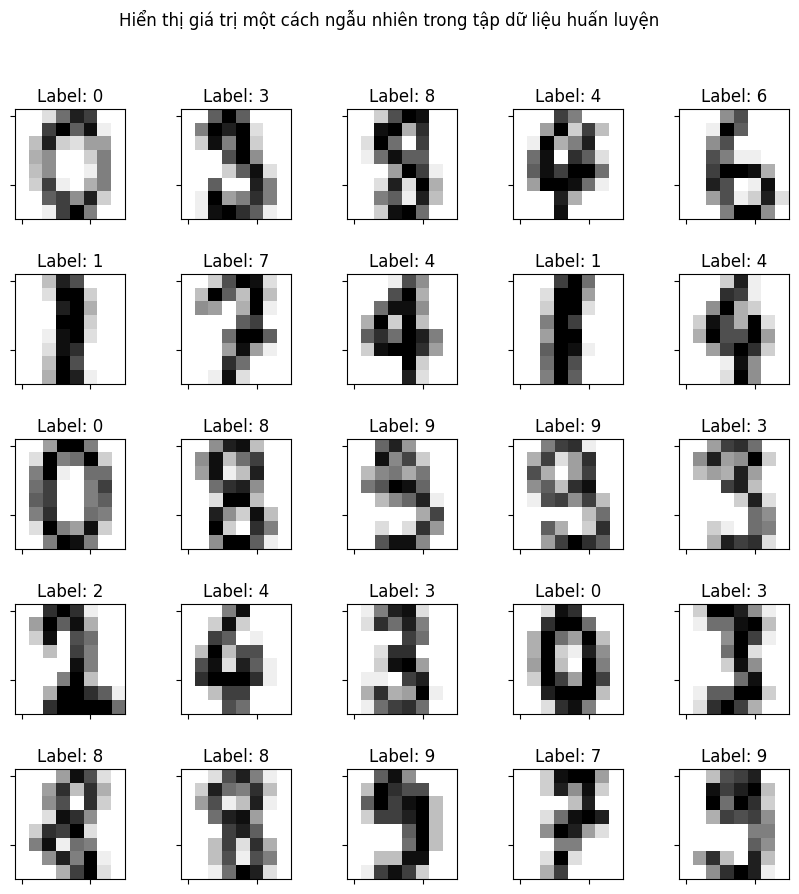

In [5]:
# Tách dữ liệu thành tập con 50% huấn luyện và 50% thử nghiệm
X_train, X_test, y_train, y_test = train_test_split(digits.images, digits.target, test_size = 0.2, random_state = 200, shuffle = False)
display_digits(X_train, y_train)

Như vậy tập dữ liệu chữ số chứa 8x8 đặc trưng, đây có lẽ một nhiệm vụ challenging. Nếu là muốn hiểu cấu trúc và quan sát dữ liệu chữ số. Thêm vào đó, dữ liệu với chỉ 2 hoặc 3 biến thì dễ dàng để grasp và cũng có thể trực quan dễ dàng. Đó hầu hết giải thích tại nên trực quan dữ liệu với sự hỗ trợ của một trong công cụ Dimensionality Reduction, tên là Principal Component Analysis (PCA). Ý tưởng trong PCA là tìm một tổ hợp tuyến tính của 2 biến mà nó chứa hầu hết thông tin. Biến mới này hoặc 'principal component' có thể thay thế 2 giá trị gốc.

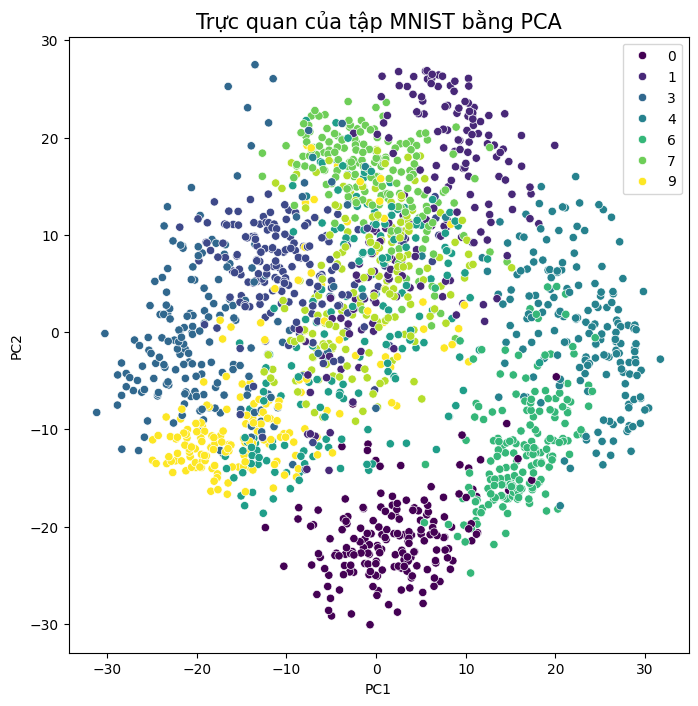

In [6]:
from sklearn.decomposition import PCA
# Tạo một mô hình PCA Randomized để lấy 2 thành phần
pca = PCA(n_components = 2)

#Khớp và chuyển dữ liệu đến mô hình
reduced_data_rpca = pca.fit_transform(digits.data)

#Tạo một mô hình PCA thông thường
pca = PCA(n_components = 2)

# Khớp và chuyển dữ liệu đế mô hình
reduced_data_pca = pca.fit_transform(digits.data)
plt.figure(figsize = (8,8))
_ = sns.scatterplot(x = reduced_data_pca[:, 0], y = reduced_data_pca[:, 1], hue = digits.target, palette = 'viridis')
_ = plt.xlabel('PC1')
_ = plt.ylabel('PC2')
_ = plt.title('Trực quan của tập MNIST bằng PCA', {'fontsize': 15}) 

### **Mô hình và kết quả**

Trước khi áp dụng phân loại và dữ liệu này, chúng ta cần flatten the images, chuyển mỗi mảng 2-D của giá trị grayscale từ định dạng (8,8) thành định dạng (64 , ). Ngay lập tức, tập dữ liệu ... sẽ được định dạnh (n_samples, n_features), ở đó n_samples là số lượng images và n_features là tổng số lượng pixels của mỗi image.

In [7]:
# Làm phẳng hình ảnh
X_train = X_train.reshape((len(X_train),-1))
X_test = X_test.reshape((len(X_test), -1))

In [8]:
#=================================
# Tạo một phân loại ở đây
# Ví dụ: ví dụ này, chúng tôi sử dụng Hồi quy Tuyến tính
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(penalty='l2', fit_intercept=True, 
                         random_state=2021, solver = 'lbfgs', 
                         max_iter = 100, verbose=1, n_jobs = 5)

In [9]:
# Học những chữ số trong tập dữ liệu con huấn luyện
clf.fit(X_train, y_train)

# Dự đoán giá trị của chữ số trong tập thử nghiệm con
predicted = clf.predict(X_test)

[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.


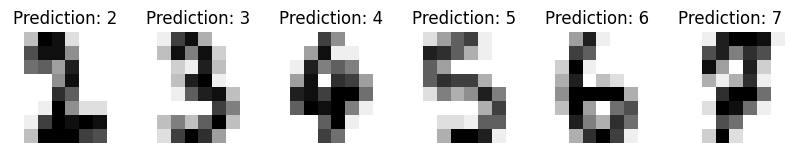

In [10]:
# Hiển thị những dự đoán
_, axes = plt.subplots(nrows=1, ncols=6, figsize=(10,3))
for ax, image, prediction in zip(axes, X_test, predicted):
    ax.set_axis_off()
    image = image.reshape(8, 8)
    ax.imshow(image, cmap = plt.cm.gray_r, interpolation = 'nearest')
    ax.set_title(f'Prediction: {prediction}')

### **Đánh giá mô hình**

Đánh giá trình diễn mô hình của bạn là bước thông dụng để giúp bạn điều tra mô hình của bạn. Nói cách khác, bạn sẽ phân tích độ chính xác của prediction của mô hình. Trong trường hợp này, accuracy là ma trận chính và có thể được sử dụng theo code sau:

In [11]:
print(f'Classification report for classifier {clf}: \n'
      f'{metrics.classification_report(y_test, predicted)} \n')

Classification report for classifier LogisticRegression(n_jobs=5, random_state=2021, verbose=1): 
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        35
           1       0.79      0.83      0.81        36
           2       1.00      1.00      1.00        35
           3       0.93      0.76      0.84        37
           4       0.97      0.92      0.94        37
           5       0.90      0.95      0.92        37
           6       0.97      0.97      0.97        37
           7       0.97      0.94      0.96        36
           8       0.78      0.88      0.83        33
           9       0.80      0.89      0.85        37

    accuracy                           0.91       360
   macro avg       0.91      0.91      0.91       360
weighted avg       0.91      0.91      0.91       360
 



accuracy của mô hình của chúng ta là 91% trên tập đang thử nghiệm. Chúng ta có thể điều tra sâu về kết quả bởi sử dụng Confusion Matrix

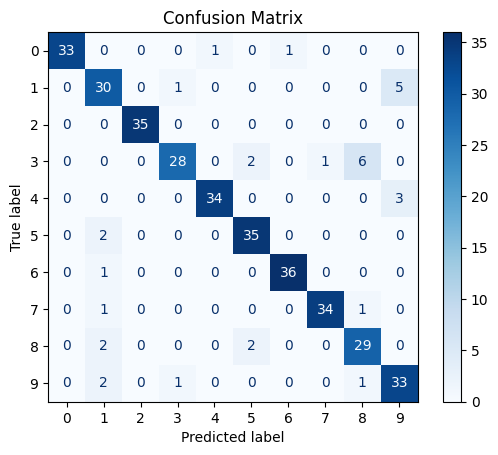

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predicted, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)

disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()

AttributeError: module 'sklearn.metrics' has no attribute 'plot_confusion_matrix'

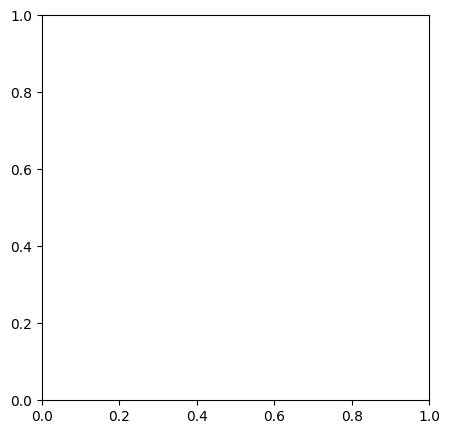

In [ ]:
plt.figure(figsize=(5, 5))
ax = plt.gca()
disp = metrics.plot_confusion_matrix(clf, X_test, y_test, ax=ax)
_ = disp.figure_.suptitle("Confusion Matrix", fontsize = 15)

Mô hình của chúng ta có thể dự đoán một trong số những chữ số một cách chính xác. Tuy nhiên, một vài mẫu thì được dữ đoán sai, những điều đó thì được hiển thị trong biểu đồ.